In [1]:
#| default_exp models.var

In [2]:
#| export

# from nbdev.showdoc import *
from __future__ import annotations
import re
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
import statsmodels.api as sm
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile,
                        expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
import copy
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

class var:
    def __init__(
        self,
        target_cols: List[str],
        lags: Dict[str, Union[int, List[int]]],
        lag_transform: Optional[Dict[str, list]] = None,
        difference: Optional[Dict[str, int]] = None,
        seasonal_diff: Optional[Dict[str, int]] = None,
        trend: Optional[Dict[str, str]] = None,
        pol_degree: Optional[Union[int, Dict[str, int]]] = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[Dict[str, List[int]]] = None,
        box_cox: Optional[Dict[str, Union[bool, float, int]]] = None,
        box_cox_biasadj: Union[bool, Dict[str, bool]] = False,
        add_constant: bool = True,
        cat_variables: Optional[List[str]] = None,
        verbose: bool = False,
    ) -> None:
        
        """"
        Initialize the VAR model with specified preprocessing and modeling parameters.

        Parameters
        ----------
        target_cols : List[str]
            List of target column names to model.
        lags : Dict[str, Union[int, List[int]]]
            Dictionary specifying lags for each target variable. Values can be an int (number of lags) or a list of specific lag indices.
        lag_transform : Optional[Dict[str, list]]
            Dictionary specifying lag-transform functions for each target variable. Each value is a list of transformation functions (e.g., rolling_mean, expanding_std) to apply to the lagged features of that target.
        difference : Optional[Dict[str, int]]
            Dictionary specifying the order of ordinary differencing to apply to each target variable. Values are integers indicating how many times to difference the series.
        seasonal_diff : Optional[Dict[str, int]]
            Dictionary specifying the seasonal period for seasonal differencing for each target variable. Values are integers indicating the seasonal lag (e.g., 12 for monthly data with yearly seasonality).
        trend : Optional[Dict[str, str]]
            Dictionary specifying the trend strategy for each target variable. Values can be 'linear' for linear trend removal or 'ets' for ETS-based trend removal.
        pol_degree : Optional[Union[int, Dict[str, int]]]
            Polynomial degree for linear trend removal. Can be a single integer applied to all targets or a dictionary specifying the degree for each target.
        ets_params : Optional[Dict[str, Any]]
            Dictionary specifying ETS model and fit parameters for each target variable when using 'ets' trend removal. Each value is a dictionary of parameters for the ExponentialSmoothing model and fitting process.
        change_points : Optional[Dict[str, List[int]]]
            Dictionary specifying change points for piecewise linear trend removal for each target variable. Values are lists of integer indices indicating where the trend should change. Only applicable when trend strategy is 'linear'.
        box_cox : Optional[Dict[str, Union[bool, float, int]]]
            Dictionary specifying whether to apply Box-Cox transformation to each target variable. Values can be a boolean (True to apply, False to skip) or a float (lambda parameter for Box-Cox transformation). If True, lambda will be estimated from the data.
        box_cox_biasadj : Union[bool, Dict[str, bool]]
            Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Can be a single boolean applied to all targets or a dictionary specifying the bias adjustment for each target.
        add_constant : bool
            If True, a constant column will be added to the regressor matrix for the VAR model. This is typically used to allow for an intercept in the model.
        cat_variables : Optional[List[str]]
            List of categorical feature column names that should be one-hot encoded. These columns will be converted to categorical dtype and then one-hot encoded, with the first category dropped to avoid multicollinearity. The original categorical columns will be replaced with the new one-hot encoded columns in the regressor matrix.
        verbose : bool
            If True, the model will print verbose messages.
        
        Returns
        -------
        None
        """

        self.target_cols = target_cols
        self.cat_variables = cat_variables
        self.cons = add_constant
        self.verbose = verbose
        self.cps = change_points

        # ── lags ──────────────────────────────────────────────────────────────
        if not isinstance(lags, dict):
            raise TypeError("lags must be a dict keyed by target column name.")
        self.n_lag = lags   # VARModel accepts int or list per key; resolved at use time

        # ── lag_transform ─────────────────────────────────────────────────────
        self.lag_transform = lag_transform

        # ── differencing ──────────────────────────────────────────────────────
        self.diffs = {col: None for col in target_cols}
        if difference is not None:
            if not isinstance(difference, dict):
                raise TypeError("difference must be a dict keyed by target column name.")
            self.diffs.update(difference)

        # ── seasonal differencing ─────────────────────────────────────────────
        self.season_diffs = {col: None for col in target_cols}
        if seasonal_diff is not None:
            if not isinstance(seasonal_diff, dict):
                raise TypeError("seasonal_diff must be a dict keyed by target column name.")
            self.season_diffs.update(seasonal_diff)

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if trend is not None and not isinstance(trend, dict):
            raise TypeError("trend must be a dict keyed by target column name.")
        

        if self.trend is not None and "ets" in trend.values():
            # ── ets params ────────────────────────────────────────────────────────────
            CONSTRUCTOR_PARAMS = {
                "trend", "damped_trend", "seasonal", "seasonal_periods",
                "initialization_method", "initial_level", "initial_trend",
                "initial_seasonal", "bounds", "dates", "freq", "missing",
            }
            FIT_PARAMS = {
                "optimized", "smoothing_level", "smoothing_trend", "smoothing_seasonal",
                "damping_trend", "remove_bias", "start_params", "method",
                "minimize_kwargs", "use_brute",
            }

            self.ets_model: Dict[str, dict] = {}
            self.ets_fit: Dict[str, dict] = {}
            if ets_params is not None:
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dict keyed by target column name.")
                for col, ttype in trend.items():
                    if ttype == "ets":
                        col_params = ets_params.get(col, {})  # flat dict per target, same as univariate
                        if not isinstance(col_params, dict):
                            raise TypeError(f"ets_params['{col}'] must be a flat dict of ETS parameters.")
                        self.ets_model[col] = {k: v for k, v in col_params.items() if k in CONSTRUCTOR_PARAMS}
                        self.ets_fit[col]   = {k: v for k, v in col_params.items() if k in FIT_PARAMS}
            else:
                # default empty dicts for all ETS targets
                for col, ttype in trend.items():
                    if ttype == "ets":
                        self.ets_model[col] = {}
                        self.ets_fit[col]   = {}

        # ── polynomial degree ─────────────────────────────────────────────────
        if isinstance(pol_degree, int):
            self.pol = {col: pol_degree for col in target_cols}
        elif isinstance(pol_degree, dict):
            self.pol = {col: pol_degree.get(col, 1) for col in target_cols}
        else:
            raise ValueError("pol_degree must be an int or a dict.")

        # ── box-cox ───────────────────────────────────────────────────────────
        # initialise biasadj regardless of box_cox
        if isinstance(box_cox_biasadj, bool):
            self.biasadj = {col: box_cox_biasadj for col in target_cols}
        elif isinstance(box_cox_biasadj, dict):
            self.biasadj = {col: box_cox_biasadj.get(col, False) for col in target_cols}
        else:
            self.biasadj = {col: False for col in target_cols}

        if box_cox is not None:
            self.box_cox: Dict[str, bool] = {}
            self.lamdas: Dict[str, Optional[float]] = {col: None for col in target_cols}
            
            if isinstance(box_cox, bool):          # ← bool before (float, int)
                self.box_cox = {col: box_cox for col in target_cols}
            elif isinstance(box_cox, (float, int)):
                self.box_cox = {col: True for col in target_cols}
                self.lamdas = {col: box_cox for col in target_cols}
            elif isinstance(box_cox, dict):
                for col, val in box_cox.items():
                    if isinstance(val, bool):          # ← bool before (float, int)
                        self.box_cox[col] = val
                        self.lamdas[col] = None
                    elif isinstance(val, (float, int)):
                        self.box_cox[col] = True
                        self.lamdas[col] = val
                    else:
                        raise ValueError(
                            f"Invalid value for box_cox['{col}']: must be bool or float."
                        )
            else:
                raise TypeError(
                    "box_cox must be a bool, float, or dict keyed by target column name."
                )
            
        else:
            self.box_cox = box_cox

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply all preprocessing transformations to df and return the cleaned DataFrame.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            for col, cats in self.cat_var.items():
                dfc[col] = pd.Categorical(dfc[col], categories=cats)
            dfc = pd.get_dummies(dfc, dtype=float)
            for pat in self.drop_categ_patterns:
                cols = list(dfc.filter(regex=pat).columns)
                if cols:
                    dfc.drop(cols, axis=1, inplace=True)

        if not all(col in dfc.columns for col in self.target_cols):
            return dfc.dropna()

        self.orig_target = dfc[self.target_cols].values # store for generating in sample residuals later
        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox is not None:
            self.is_zeros: Dict[str, bool] = {} # track if shift was applied for each target
            self.trans_data: Dict[str, np.ndarray] = {} # store transformed data for in-sample residual calculations
            for col in self.target_cols:
                if self.box_cox.get(col, False): # only apply if box_cox is True for this target
                    self.is_zeros[col] = (dfc[col] < 1).any()
                    trans_data, self.lamdas[col] = box_cox_transform(
                        x=dfc[col], shift=self.is_zeros[col], box_cox_lmda=self.lamdas[col]
                    ) # returns transformed data and lambda. If lambda is not provided, it is estimated from the data.
                    dfc[col] = trans_data
                    self.trans_data[col] = trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.orig_targets: Dict[str, pd.Series] = {}
            self.trend_models: Dict[str, Any] = {}

            for col, ttype in self.trend.items():
                self.orig_targets[col] = dfc[col].copy()

                if ttype == "linear":
                    bps = self.cps.get(col) if self.cps else None
                    if bps:
                        trend_vals, model_fit, _ = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col],
                            breakpoints=bps, type='piecewise'
                        )
                    else:
                        trend_vals, model_fit, _ = lr_trend_model(
                            self.orig_targets[col], degree=self.pol[col]
                        )
                    dfc[col] = dfc[col] - trend_vals
                    self.trend_models[col] = model_fit
                    
                elif ttype == "ets":
                    model_fit = ExponentialSmoothing(
                        self.orig_targets[col], **self.ets_model[col]
                    ).fit(**self.ets_fit[col])
                    dfc[col] = dfc[col] - model_fit.fittedvalues.values
                    self.trend_models[col] = model_fit

                else:
                    raise ValueError(
                        f"Unknown trend type '{ttype}' for '{col}'. Use 'linear' or 'ets'."
                    )

        # ── Ordinary differencing ─────────────────────────────────────────────
        self.origs: Dict[str, list] = {}
        for col, d in self.diffs.items():
            if d is not None:
                self.origs[col] = dfc[col].tolist()
                dfc[col] = np.diff(dfc[col], n=d, prepend=np.repeat(np.nan, d))

        # ── Seasonal differencing ─────────────────────────────────────────────
        self.orig_ds: Dict[str, list] = {}
        for col, s in self.season_diffs.items():
            if s is not None:
                self.orig_ds[col] = dfc[col].tolist()
                dfc[col] = seasonal_diff(dfc[col], s)

        # ── Lag features ──────────────────────────────────────────────────────
        if self.n_lag is not None:
            for col, lags in self.n_lag.items():
                lag_used = lags if isinstance(lags, list) else range(1, lags + 1)
                for lg in lag_used:
                    dfc[f"{col}_lag_{lg}"] = dfc[col].shift(lg)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for idx, (col, funcs) in enumerate(self.lag_transform.items()):
                for func in funcs:
                    if isinstance(func, (expanding_std, expanding_mean)):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[col])
                    elif isinstance(func, expanding_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    elif isinstance(func, rolling_quantile):
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[col])
                    else:
                        dfc[f"trg{idx}_{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[col])

        return dfc.dropna()

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        
        """
        Fit the VAR model to the provided DataFrame.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.
            
        Returns
        -------
        None
        """
        if self.cat_variables is not None:
            self.cat_var = {
                c: sorted(df[c].drop_duplicates().tolist())
                for c in self.cat_variables
            }
            # self.drop_categ = [self.cat_var[c][0] for c in self.cat_variables]

            self.drop_categ_patterns = []
            for c in self.cat_variables:
                base = sorted(df[c].drop_duplicates().tolist())[0]
                self.drop_categ_patterns.append(rf"^{re.escape(c)}_{re.escape(str(base))}$")

        df = self.data_prep(df)
        X = df.drop(columns=self.target_cols)
        if self.cons:
            X = sm.add_constant(X)
        X = X.apply(pd.to_numeric, errors='raise')
        self.X = np.array(X)
        self.y = np.array(df[self.target_cols])
        self.coeffs = np.linalg.lstsq(self.X, self.y, rcond=None)[0]

    # ─────────────────────────────────────────────────────────────────────────
    # PREDICT
    # ─────────────────────────────────────────────────────────────────────────

    def predict(self, X) -> np.ndarray:
        """
        Predict with the fitted coefficient matrix.

        Parameters
        ----------
        X : array-like
            Feature vector or matrix.

        Returns
        -------
        np.ndarray
            Predicted values for each target.
        """
        return np.dot(self.coeffs.T, np.array(X).T)
    
    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        fitted_values = self.predict(self.X).T
        fit_len = len(fitted_values)
        self.fitted_values = {col: fitted_values[:, i] for i, col in enumerate(self.target_cols)}
        
        self.in_samp_resids = {col: self.y[:, i] - self.fitted_values[col] for i, col in enumerate(self.target_cols)}
        self.fitted_values = {col: self.orig_target[-fit_len:, i] + self.in_samp_resids[col] for i, col in enumerate(self.target_cols)} # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
        if self.box_cox is not None:
            for i, col in enumerate(self.target_cols):
                if self.box_cox.get(col, False):
                    bc_fitted = self.trans_data[col][-fit_len:] + self.in_samp_resids[col]
                    self.fitted_values[col] = back_box_cox_transform(
                        y_pred=bc_fitted, lmda=self.lamdas[col],
                        shift=self.is_zeros.get(col, False), box_cox_biasadj=self.biasadj[col]
                    )
                    self.in_samp_resids[col] = self.orig_target[-fit_len:, i] - self.fitted_values[col]

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _ic_base(self):
        res = self.y - self.predict(self.X).T
        K = self.y.shape[1]
        p_lag = list(self.n_lag.values())
        p = p_lag[0] if isinstance(p_lag[0], int) else len(p_lag[0])
        q = self.X.shape[1] - p
        total_params = (K ** 2) * p + K * q
        n = self.y.shape[0]
        det_cov = np.log(np.linalg.det(np.cov(res, rowvar=False)))
        return total_params, n, det_cov

    @property
    def aic(self) -> float:
        total_params, n, det_cov = self._ic_base()
        return det_cov + (2 * total_params) / n

    @property
    def aicc(self) -> float:
        total_params, n, det_cov = self._ic_base()
        aic = det_cov + (2 * total_params) / n
        return aic + (2 * total_params * (total_params + 1)) / (n - total_params - 1)

    @property
    def bic(self) -> float:
        total_params, n, det_cov = self._ic_base()
        return det_cov + total_params * np.log(n) / n

    @property
    def hqc(self) -> float:
        total_params, n, det_cov = self._ic_base()
        return det_cov + 2 * total_params * np.log(np.log(n)) / n

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> Dict[str, np.ndarray]:
        """
        Generate forecasts for H future time steps.

        Parameters
        ----------
        H : int
            Forecast horizon (number of steps ahead to predict).
        exog : Optional[pd.DataFrame]
            Future exogenous regressors (must contain at least H rows).

        Returns
        -------
        Dict[str, np.ndarray]
            Forecasted values for each target, keyed by column name.
        """
        # Rolling history for each target
        y_lists: Dict[str, list] = {
            col: self.y[:, i].tolist()
            for i, col in enumerate(self.target_cols)
        }

        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cons:
                if exog.shape[0] == 1:
                    exog.insert(0, 'const', 1)
                else:
                    exog = sm.add_constant(exog)
            exog = np.array(self.data_prep(exog))

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        trend_forecasts: Dict[str, np.ndarray] = {}

        if self.trend is not None:
            for col, ttype in self.trend.items():
                if ttype == "linear":
                    bps = self.cps.get(col) if self.cps else None
                    trend_forecasts[col], _ = forecast_trend(
                        model=self.trend_models[col], H=H,
                        start=self.len, degree=self.pol[col], breakpoints=bps
                    )
                elif ttype == "ets":
                    trend_forecasts[col] = np.array(self.trend_models[col].forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────
        raw_forecasts: Dict[str, list] = {col: [] for col in self.target_cols}

        for t in range(H):
            # Exogenous features for step t
            if exog is not None:
                exo_inp = exog[t].tolist()
            else:
                exo_inp = [1] if self.cons else []

            # Lag features
            inp_lag = []
            if self.n_lag is not None:
                for col, lags in self.n_lag.items():
                    lag_used = lags if isinstance(lags, list) else range(1, lags + 1)
                    inp_lag.extend([y_lists[col][-x] for x in lag_used])

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                for col, funcs in self.lag_transform.items():
                    series_array = np.array(y_lists[col])
                    for func in funcs:
                        transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            inp = exo_inp + inp_lag + transform_lag
            pred = self.predict(inp)

            for i, col in enumerate(self.target_cols):
                raw_forecasts[col].append(pred[i])
                y_lists[col].append(pred[i])

        # ── Post-processing ───────────────────────────────────────────────────
        forecasts: Dict[str, np.ndarray] = {
            col: np.array(raw_forecasts[col]) for col in self.target_cols
        }

        # Add back removed trend
        if self.trend is not None:
            for col in self.trend:
                forecasts[col] = forecasts[col] + trend_forecasts[col]

        # Invert seasonal differencing
        for col, s in self.season_diffs.items():
            if s is not None:
                forecasts[col] = invert_seasonal_diff(self.orig_ds[col], forecasts[col], s)

        # Invert ordinary differencing
        for col, d in self.diffs.items():
            if d is not None:
                forecasts[col] = undiff_ts(self.origs[col], forecasts[col], d)

        # Non-negativity
        for col in forecasts:
            forecasts[col] = np.array([max(0, x) for x in forecasts[col]])

        # Invert Box-Cox
        if self.box_cox is not None:
            for col in self.target_cols:
                if self.box_cox.get(col, False):
                    forecasts[col] = back_box_cox_transform(
                        y_pred=forecasts[col],
                        lmda=self.lamdas[col],
                        shift=self.is_zeros.get(col, False),
                        box_cox_biasadj=self.biasadj[col]
                )

        return forecasts
    
    def cross_validate(self,
                       df: pd.DataFrame,
                       target_col: str,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None,
                       ) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
        """
        Perform cross-validation.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataframe.
        target_col : str
            Target variable for evaluation.
        cv_split : int
            Number of cross-validation folds.
        test_size : int
            Test size per fold.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, optional
            Step size for rolling window. Default is 1.
        h_split_point : int, optional
            Point to split the test set for separate evaluation. Default is None.
    
        Returns
        -------
        pd.DataFrame
            DataFrame with averaged cross-validation metric scores.
        """

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}

        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test, y_test = test.drop(columns=self.target_cols), np.array(test[target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            forecasts = self.forecast(test_size, exog_t)[target_col]

            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, forecasts, train[target_col])
                else:
                    eval_val = m(y_test, forecasts)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = forecasts[:h_split_point], forecasts[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_cols]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_cols]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)

            ## store results for this split
            all_forecasts = self.forecast(test_size, exog_t)
            actuals = {f"actual_{col}": test[col].values for col in self.target_cols}
            all_forecasts_dict = {f"forecast_{col}": all_forecasts[col] for col in self.target_cols}
            split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                            "split": np.repeat(f"fold_{idx+1}", len(test))}
            
            split_results.update(actuals)
            split_results.update(all_forecasts_dict)

            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)
                
        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        
        self.cv_summary = overall_performance
        return cv_df_

    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "var"



In [3]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [4]:
#| echo: false
docments(var, full=True)
DocmentTbl(var)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| target_cols | List[str] |  | List of target column names to model. |
| lags | Dict[str, Union[int, List[int]]] |  | Dictionary specifying lags for each target variable. Values can be an int (number of lags) or a list of specific lag indices. |
| lag_transform | Optional[Dict[str, list]] | None | Dictionary specifying lag-transform functions for each target variable. Each value is a list of transformation functions (e.g., rolling_mean, expanding_std) to apply to the lagged features of that target. |
| difference | Optional[Dict[str, int]] | None | Dictionary specifying the order of ordinary differencing to apply to each target variable. Values are integers indicating how many times to difference the series. |
| seasonal_diff | Optional[Dict[str, int]] | None | Dictionary specifying the seasonal period for seasonal differencing for each target variable. Values are integers indicating the seasonal lag (e.g., 12 for monthly data with yearly seasonality). |
| trend | Optional[Dict[str, str]] | None | Dictionary specifying the trend strategy for each target variable. Values can be 'linear' for linear trend removal or 'ets' for ETS-based trend removal. |
| pol_degree | Optional[Union[int, Dict[str, int]]] | 1 | Polynomial degree for linear trend removal. Can be a single integer applied to all targets or a dictionary specifying the degree for each target. |
| ets_params | Optional[Dict[str, Any]] | None | Dictionary specifying ETS model and fit parameters for each target variable when using 'ets' trend removal. Each value is a dictionary of parameters for the ExponentialSmoothing model and fitting process. |
| change_points | Optional[Dict[str, List[int]]] | None | Dictionary specifying change points for piecewise linear trend removal for each target variable. Values are lists of integer indices indicating where the trend should change. Only applicable when trend strategy is 'linear'. |
| box_cox | Optional[Dict[str, Union[bool, float, int]]] | None | Dictionary specifying whether to apply Box-Cox transformation to each target variable. Values can be a boolean (True to apply, False to skip) or a float (lambda parameter for Box-Cox transformation). If True, lambda will be estimated from the data. |
| box_cox_biasadj | Union[bool, Dict[str, bool]] | False | Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Can be a single boolean applied to all targets or a dictionary specifying the bias adjustment for each target. |
| add_constant | bool | True | If True, a constant column will be added to the regressor matrix for the VAR model. This is typically used to allow for an intercept in the model. |
| cat_variables | Optional[List[str]] | None | List of categorical feature column names that should be one-hot encoded. These columns will be converted to categorical dtype and then one-hot encoded, with the first category dropped to avoid multicollinearity. The original categorical columns will be replaced with the new one-hot encoded columns in the regressor matrix. |
| verbose | bool | False | If True, the model will print verbose messages. |
| **Returns** | **None** |  |  |

In [5]:
#| echo: false
show_doc(var.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/var.py#L304){target="_blank" style="float:right; font-size:smaller"}

### var.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing the target and any feature columns.
)->None:


```

*Fit the VAR model to the provided DataFrame.*

In [6]:
#| echo: false
DocmentTbl(var.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing the target and any feature columns. |
| **Returns** | **None** |  |

In [7]:
#| echo: false
show_doc(var.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/var.py#L430){target="_blank" style="float:right; font-size:smaller"}

### var.forecast

```python

def forecast(
    H:int, # Forecast horizon (number of steps ahead to predict).
    exog:Optional[pd.DataFrame]=None, # Future exogenous regressors (must contain at least H rows).
)->Dict[str, np.ndarray]: # Forecasted values for each target, keyed by column name.


```

*Generate forecasts for H future time steps.*

In [8]:
#| echo: false
DocmentTbl(var.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon (number of steps ahead to predict). |
| exog | Optional[pd.DataFrame] | None | Future exogenous regressors (must contain at least H rows). |
| **Returns** | **Dict[str, np.ndarray]** |  | **Forecasted values for each target, keyed by column name.** |

In [9]:
#| echo: false
show_doc(var.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/var.py#L548){target="_blank" style="float:right; font-size:smaller"}

### var.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # Input dataframe.
    target_col:str, # Target variable for evaluation.
    cv_split:int, # Number of cross-validation folds.
    test_size:int, # Test size per fold.
    metrics:List[Callable], # Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
    step_size:int=1, # Step size for rolling window. Default is 1.
    h_split_point:Optional[int]=None, # Point to split the test set for separate evaluation. Default is None.
)->Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]: # DataFrame with averaged cross-validation metric scores.


```

*Perform cross-validation.*

In [10]:
#| echo: false
DocmentTbl(var.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Input dataframe. |
| target_col | str |  | Target variable for evaluation. |
| cv_split | int |  | Number of cross-validation folds. |
| test_size | int |  | Test size per fold. |
| metrics | List[Callable] |  | Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores. |
| step_size | int | 1 | Step size for rolling window. Default is 1. |
| h_split_point | Optional[int] | None | Point to split the test set for separate evaluation. Default is None. |
| **Returns** | **Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]** |  | **DataFrame with averaged cross-validation metric scores.** |

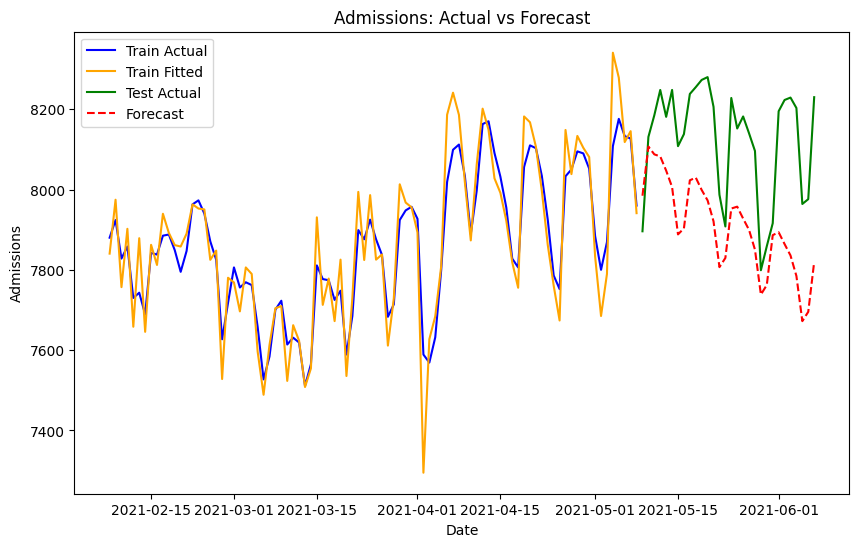

In [11]:
#| hide

from peshbeen.datasets import load_admission_calls
## get day of week and month as features from the date index
load_admission_calls["day_of_week"] = load_admission_calls.index.dayofweek
load_admission_calls["month"] = load_admission_calls.index.month
train = load_admission_calls[:-30]
test = load_admission_calls[-30:]

cat_variables = ["day_of_week", "month"]
var_model = var(target_cols=['admissions', "calls"], lags={'admissions': 7, "calls": 7}, box_cox={'admissions': False, "calls": False}, cat_variables=cat_variables,
                  box_cox_biasadj=True)

var_model.fit(train)
var_model.predict_in_sample()
forecasts = var_model.forecast(H=30, exog=test[cat_variables])

# plot actual vs forecasted for both targets
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], var_model.fitted_values["admissions"][-90:], label='Train Fitted', color='orange')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts['admissions'], label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Admissions: Actual vs Forecast')
plt.legend()
plt.show()


In [12]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cvdf = var_model.cross_validate(df=load_admission_calls, target_col='calls', cv_split=3, test_size=30, metrics=mtrcs)